# Obtención de medidas de componentes de ERP

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import pandas as pd

In [38]:
tmin = 0.125
tmax = 0.225
duration = tmax - tmin
channels = ['FCZ', 'CZ', 'FZ']

## Carga de datos de sujetos y de procesamiento de los EEG

In [39]:
# Cargar reporte de procesamiento
PREP_DIR = Path().resolve().parent / 'preprocessing'
report = pd.read_csv(PREP_DIR / 'log_processing.csv')
report = report.set_index('Subject')
report.head()

,Bad channels,Total bad channels,Bad ICA components,Total bad ICA components,Total bad epochs
Subject,,,,,
21100,"['POZ', 'FC5', 'PZ', 'PO3']",4,"[np.int64(0), np.int64(23), np.int64(1), 2, 4,...",12,4
21101,"['AF7', 'FP2', 'PO7', 'AF8', 'PO4', 'FP1']",6,"[np.int64(2), np.int64(14), 0, 3, 4, 6, 7, 11,...",11,3
21102,"['P1', 'PO3']",2,"[np.int64(0), np.int64(29), 18, 21, 28, 38, 42...",9,0
21103,"['P1', 'P2', 'P4', 'P10']",4,"[np.int64(0), np.int64(2), 9, 26, 39, 40]",6,70
21104,"['P8', 'IZ', 'FPZ', 'FP2', 'P2', 'T8']",6,"[np.int64(1), np.int64(2), 34, 43]",4,48


In [40]:
BEHAVIORAL_DIR = Path().resolve().parent / 'data' / 'behavioral'

datos_sujetos = pd.read_csv(BEHAVIORAL_DIR / 'Datos_IAT_comportamentales_personales.csv')
datos_sujetos = datos_sujetos.set_index('subject')
# Reemplazar "control" por "nonvictim"
datos_sujetos['type'] = datos_sujetos['type'].replace({'control':'nonvictim'})
# Reemplazar "control" por "nonvictim"
datos_sujetos['group'] = datos_sujetos['group'].replace({'control':'nonvictim'})
datos_sujetos.head()

,type,exposure_level,group,victim_self,victim_self_id,age,scholarship,gender,laterality,dscore_0,...,DAP,AAP,TPA,TPV,EASPA,ANA,BN,ANC,AGA.1,TAPV
subject,,,,,,,,,,,,,,,,,,,,,
21100,excombatant,high,exguerrilla,yes,yes,19,11,F,D,-0.197633,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21101,excombatant,high,exparamilitar,yes,yes,46,11,M,D,-0.116918,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
21102,excombatant,low,exparamilitar,yes,yes,31,11,M,D,0.473119,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21103,excombatant,high,exparamilitar,yes,yes,42,18,M,D,0.214867,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21104,excombatant,high,exparamilitar,yes,yes,38,11,M,D,0.423545,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
features_to_merge = [
    'type',
    'group',
    'victim_self',
    'exposure_level',
    'age',
    'gender',
    'scholarship',
    'laterality',
    ]

report = report.merge(
    datos_sujetos[features_to_merge], 
    left_index=True, 
    right_index=True
    )

# Delete control type and ex-both-sides group
#report = report[report['group'] != 'ex-both-sides']

report.head()

,Bad channels,Total bad channels,Bad ICA components,Total bad ICA components,Total bad epochs,type,group,victim_self,exposure_level,age,gender,scholarship,laterality,IAT_level
Subject,,,,,,,,,,,,,,
21100,"['POZ', 'FC5', 'PZ', 'PO3']",4,"[np.int64(0), np.int64(23), np.int64(1), 2, 4,...",12,4,excombatant,exguerrilla,yes,high,19,F,11,D,High
21101,"['AF7', 'FP2', 'PO7', 'AF8', 'PO4', 'FP1']",6,"[np.int64(2), np.int64(14), 0, 3, 4, 6, 7, 11,...",11,3,excombatant,exparamilitar,yes,high,46,M,11,D,Medium
21102,"['P1', 'PO3']",2,"[np.int64(0), np.int64(29), 18, 21, 28, 38, 42...",9,0,excombatant,exparamilitar,yes,low,31,M,11,D,High
21103,"['P1', 'P2', 'P4', 'P10']",4,"[np.int64(0), np.int64(2), 9, 26, 39, 40]",6,70,excombatant,exparamilitar,yes,high,42,M,18,D,Medium
21104,"['P8', 'IZ', 'FPZ', 'FP2', 'P2', 'T8']",6,"[np.int64(1), np.int64(2), 34, 43]",4,48,excombatant,exparamilitar,yes,high,38,M,11,D,High


## Análisis de artefactos

In [45]:
report.groupby('type')[
	['Total bad epochs', 'Total bad channels', 'Total bad ICA components']
].agg(['mean', 'std', 'min', 'max'])

Total bad epochs                     Total bad channels            \
                        mean        std min  max               mean       std   
type                                                                            
excombatant        15.051724  22.475267   0  104           4.844828  3.088188   
nonvictim          10.625000  18.881649   0   67           3.000000  2.309401   
victim              9.347826   8.621372   0   35           6.347826  3.458963   

                    Total bad ICA components                    
            min max                     mean       std min max  
type                                                            
excombatant   0  12                 9.586207  4.530731   2  26  
nonvictim     0   8                 8.875000  3.844910   3  15  
victim        1  14                10.869565  4.929543   2  20

In [46]:
# Sujetos con muchos artefactos
bad_subjects = report[
	(report['Total bad epochs'] > 130 * 0.3)
	| (report['Total bad channels'] > 64 * 0.3)
	| (report['Total bad ICA components'] > 64 * 0.3)
]

bad_subjects

,Bad channels,Total bad channels,Bad ICA components,Total bad ICA components,Total bad epochs,type,group,victim_self,exposure_level,age,gender,scholarship,laterality,IAT_level
Subject,,,,,,,,,,,,,,
21103,"['P1', 'P2', 'P4', 'P10']",4,"[np.int64(0), np.int64(2), 9, 26, 39, 40]",6,70,excombatant,exparamilitar,yes,high,42,M,18,D,Medium
21104,"['P8', 'IZ', 'FPZ', 'FP2', 'P2', 'T8']",6,"[np.int64(1), np.int64(2), 34, 43]",4,48,excombatant,exparamilitar,yes,high,38,M,11,D,High
21106,"['PZ', 'P1', 'T7']",3,"[np.int64(1), np.int64(0), np.int64(9), 4, 11,...",9,46,excombatant,exguerrilla,no,low,28,M,5,D,Medium
21129,[],0,"[np.int64(0), np.int64(7), 2, 3, 4, 5, 6, 9, 1...",17,77,excombatant,exparamilitar,yes,high,30,M,10,D,High
21135,"['P1', 'OZ', 'IZ', 'O1', 'P2', 'PO3', 'POZ']",7,"[np.int64(5), np.int64(0), 15, 16, 22, 30, 32,...",8,58,excombatant,exparamilitar,yes,high,50,M,14,D,Low
21139,['IZ'],1,"[np.int64(0), 7, 9, 14, 19, 22, 23, 31, 32, 43...",11,65,excombatant,exparamilitar,no,high,38,M,9,D,Low
22116,['P7'],1,"[np.int64(8), np.int64(9), 33]",3,67,nonvictim,nonvictim,no,low,27,M,11,D,Low
23002,"['P1', 'AF7', 'PO3', 'P9', 'POZ', 'T8']",6,"[np.int64(3), np.int64(1), np.int64(0), np.int...",26,0,excombatant,exparamilitar,no,low,48,M,6,D,Low
23012,"['C3', 'P6', 'P2', 'PO3', 'PO7', 'TP7']",6,"[np.int64(0), 29, 35, 37]",4,104,excombatant,exguerrilla,yes,high,43,M,5,D,High


In [47]:
bad_subjects['type'].value_counts()

type
excombatant    8
nonvictim      1
victim         1
Name: count, dtype: int64

In [48]:
preserved = report[~report.index.isin(bad_subjects.index)]
preserved.index = preserved.index.astype(str)
preserved.head()

,Bad channels,Total bad channels,Bad ICA components,Total bad ICA components,Total bad epochs,type,group,victim_self,exposure_level,age,gender,scholarship,laterality,IAT_level
Subject,,,,,,,,,,,,,,
21100,"['POZ', 'FC5', 'PZ', 'PO3']",4,"[np.int64(0), np.int64(23), np.int64(1), 2, 4,...",12,4,excombatant,exguerrilla,yes,high,19,F,11,D,High
21101,"['AF7', 'FP2', 'PO7', 'AF8', 'PO4', 'FP1']",6,"[np.int64(2), np.int64(14), 0, 3, 4, 6, 7, 11,...",11,3,excombatant,exparamilitar,yes,high,46,M,11,D,Medium
21102,"['P1', 'PO3']",2,"[np.int64(0), np.int64(29), 18, 21, 28, 38, 42...",9,0,excombatant,exparamilitar,yes,low,31,M,11,D,High
21105,"['P1', 'IZ', 'P3', 'O1', 'P2', 'PO3', 'PO7', '...",10,"[np.int64(0), np.int64(3), 4, 9, 12, 23, 25, 2...",9,4,excombatant,exparamilitar,yes,high,48,M,8,D,High
21107,"['P1', 'T7', 'IZ', 'PO7', 'PZ']",5,"[np.int64(0), np.int64(1), np.int64(4), 3, 6, ...",14,9,excombatant,exguerrilla,no,high,25,M,11,D,Low


In [49]:
preserved['type'].value_counts()

type
excombatant    50
victim         22
nonvictim      15
Name: count, dtype: int64

## Carga de ERPs

In [78]:
EEG_DIR = Path().resolve().parent / 'data' / 'eeg-processed'
eeg_paths = sorted(EEG_DIR.glob('*.fif'))

In [79]:
evocados_co = {}
evocados_in = {}

for ruta in eeg_paths:
    epochs = mne.read_epochs(ruta)
    subject_id = ruta.stem.split('_')[0]
    evoked_co = epochs['12', '13', '14', '15', '16', '17', '18', '19'].average()
    #evoked_co = evoked_co.filter(l_freq=None, h_freq=10.0)
    evocados_co[subject_id] = evoked_co
    evoked_in = epochs['24', '25', '26', '27', '28', '29', '30', '31'].average()
    #evoked_in = evoked_in.filter(l_freq=None, h_freq=10.0)
    evocados_in[subject_id] = evoked_in

Reading C:\Users\jhquiza\repos\iat-eeg\data\eeg-processed\21100_epo.fif ...


    Found the data of interest:
        t =    -199.22 ...    2000.00 ms
        0 CTF compensation matrices available
Not setting metadata
145 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\jhquiza\repos\iat-eeg\data\eeg-processed\21101_epo.fif ...
    Found the data of interest:
        t =    -199.22 ...    2000.00 ms
        0 CTF compensation matrices available
Not setting metadata
154 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\jhquiza\repos\iat-eeg\data\eeg-processed\21102_epo.fif ...
    Found the data of interest:
        t =    -199.22 ...    2000.00 ms
        0 CTF compensation matrices available
Not setting metadata
130 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\jhquiza\repos\iat-eeg\data\eeg-processed\21103_epo.fif ...
    Found the data of interest:
        t =    -199.22 ...    2000.00 ms
        0 CTF compens

In [147]:
victimas_co = [evocados_co[sujeto] for sujeto in preserved[preserved['type'] == 'victim'].index]
victimas_in = [evocados_in[sujeto] for sujeto in preserved[preserved['type'] == 'victim'].index]
no_victimas_co = [evocados_co[sujeto] for sujeto in preserved[preserved['type'] == 'nonvictim'].index]
no_victimas_in = [evocados_in[sujeto] for sujeto in preserved[preserved['type'] == 'nonvictim'].index]

In [148]:
victimas_co_grand_average = mne.grand_average(victimas_co)
victimas_in_grand_average = mne.grand_average(victimas_in)

Identifying common channels ...


Identifying common channels ...


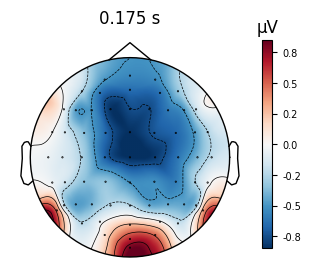

In [149]:
victimas_co_grand_average.plot_topomap(
    times=[0.175],
    res=300,
    size=2
    );

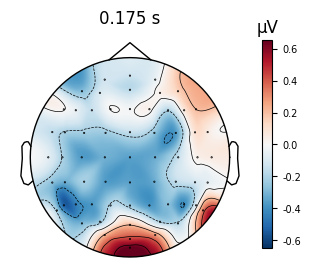

In [150]:
victimas_in_grand_average.plot_topomap(
    times=[0.175],
    res=300,
    size=2
    );

In [151]:
no_victimas_co_grand_average = mne.grand_average(no_victimas_co)
no_victimas_in_grand_average = mne.grand_average(no_victimas_in)

Identifying common channels ...


Identifying common channels ...


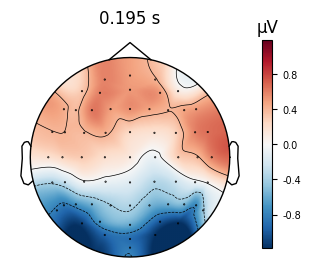

In [152]:
no_victimas_co_grand_average.plot_topomap(
    times=[0.195],
    res=300,
    size=2
    );

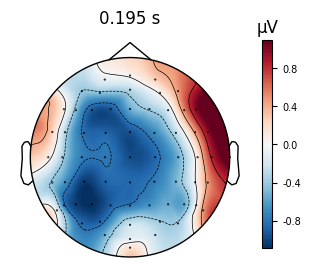

In [153]:
no_victimas_in_grand_average.plot_topomap(
    times=[0.195],
    res=300,
    size=2
    );

In [194]:
victimas_co_cluster = [erp.copy().crop(tmin=tmin, tmax=tmax).pick(channels) for erp in victimas_co]
victimas_in_cluster = [erp.copy().crop(tmin=tmin, tmax=tmax).pick(channels) for erp in victimas_in]
no_victimas_co_cluster = [erp.copy().crop(tmin=tmin, tmax=tmax).pick(channels) for erp in no_victimas_co]
no_victimas_in_cluster = [erp.copy().crop(tmin=tmin, tmax=tmax).pick(channels) for erp in no_victimas_in]

evokeds = {
    'Victims - Congruent': victimas_co_cluster,
    'Victims - Incongruent': victimas_in_cluster,
    'Non-Victims - Congruent': no_victimas_co_cluster,
    'Non-Victims - Incongruent': no_victimas_in_cluster
}


combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


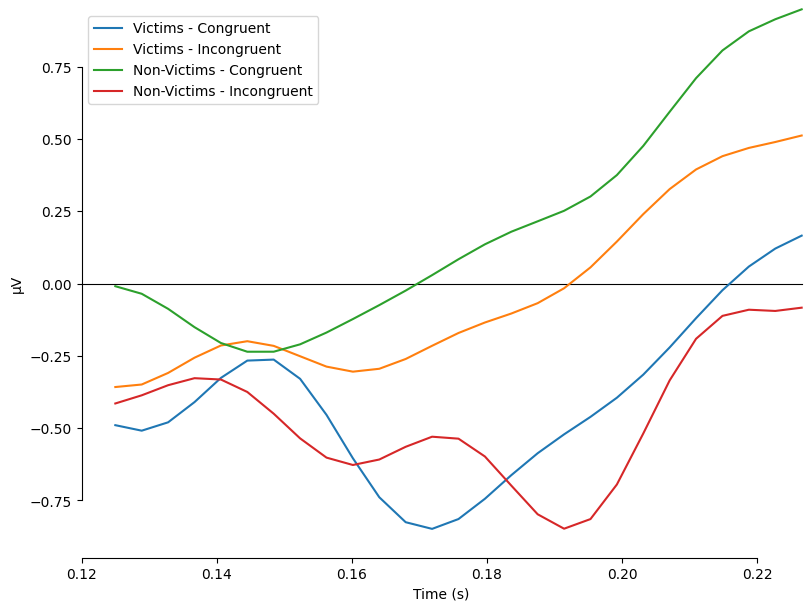

[<Figure size 800x600 with 1 Axes>]

In [195]:
mne.viz.plot_compare_evokeds(
    evokeds=evokeds,
    combine='mean',
    ci=False,
    split_legend=True
)

## Medidas

In [53]:
# Función que calcula el erp grand-average de una ROI dada una lista de canales
def ROI_evoked(evocado, canales):
    lista_canales = evocado.ch_names
    lista_indices = []
    for canal in canales:
        indice = lista_canales.index(canal)
        lista_indices.append(indice)
    ROI_evocado = mne.channels.combine_channels(evocado, groups={'ROI':lista_indices})
    return ROI_evocado

# Función que entrega diccionarios de erp de ROIs por tipo de ensayo
def rois(canales, df_sujetos, evocados_co, evocados_in, t_min=.0, t_max=.8):
    ROI_co = {}
    ROI_in = {}
    ROI_dif = {}
    
    for sujeto in df_sujetos.index:
        ROI_co[sujeto] = ROI_evoked(evocados_co[sujeto],canales).crop(
            tmin=t_min,
            tmax=t_max
            )
        ROI_in[sujeto] = ROI_evoked(evocados_in[sujeto],canales).crop(
            tmin=t_min,
            tmax=t_max
            )
        data_dif = ROI_co[sujeto].data - ROI_in[sujeto].data
        ROI_dif[sujeto] = mne.EvokedArray(
            data=data_dif, 
            info=ROI_in[sujeto].info, 
            tmin=ROI_in[sujeto].tmin
            )

    return ROI_co, ROI_in, ROI_dif

In [54]:
ROI_co, ROI_in, ROI_dif = rois(
    canales=channels,
    df_sujetos=preserved,
    evocados_co=evocados_co, 
    evocados_in=evocados_in,
    )

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode

In [55]:
# Cálculo de media de un erp de un ROI
def medidas(evoked, tmin, tmax):
    evoked_ROI = evoked.copy()
    evoked_ROI.crop(tmin = tmin, tmax = tmax)
    data = evoked_ROI.to_data_frame(time_format = None)
    data.set_index('time',inplace=True)
    mean_amplitude = data.mean()
    peak_amplitude = data.min()
    peak_latency = data.idxmin()
    return mean_amplitude, peak_amplitude, peak_latency

In [56]:
mean_amplitude_co = {}
mean_amplitude_in = {}
mean_amplitude_dif = {}
peak_amplitude_co = {}
peak_amplitude_in = {}
peak_amplitude_dif = {}
peak_latency_co = {}
peak_latency_in = {}
peak_latency_dif = {}

for sujeto in preserved.index:
    mean_amplitude_co[sujeto], peak_amplitude_co[sujeto], peak_latency_co[sujeto] = medidas(ROI_co[sujeto], tmin=tmin, tmax=tmax)
    mean_amplitude_in[sujeto], peak_amplitude_in[sujeto], peak_latency_in[sujeto] = medidas(ROI_in[sujeto], tmin=tmin, tmax=tmax)
    mean_amplitude_dif[sujeto], peak_amplitude_dif[sujeto], peak_latency_dif[sujeto] = medidas(ROI_dif[sujeto], tmin=tmin, tmax=tmax)

print(mean_amplitude_co['21100'].iloc[0], peak_amplitude_co['21100'].iloc[0], peak_latency_co['21100'].iloc[0])

0.2988262719495286 -0.11740710267361898 0.16015625


In [57]:
mean_ROI_co_df = pd.DataFrame(mean_amplitude_co).T.rename(columns={'ROI':'mean_amplitude_co'})
mean_ROI_in_df = pd.DataFrame(mean_amplitude_in).T.rename(columns={'ROI':'mean_amplitude_in'})
mean_ROI_dif_df = pd.DataFrame(mean_amplitude_dif).T.rename(columns={'ROI':'mean_amplitude_dif'})
peak_ROI_co_df = pd.DataFrame(peak_amplitude_co).T.rename(columns={'ROI':'peak_amplitude_co'})
peak_ROI_in_df = pd.DataFrame(peak_amplitude_in).T.rename(columns={'ROI':'peak_amplitude_in'})
peak_ROI_dif_df = pd.DataFrame(peak_amplitude_dif).T.rename(columns={'ROI':'peak_amplitude_dif'})
peak_latency_ROI_co_df = pd.DataFrame(peak_latency_co).T.rename(columns={'ROI':'peak_latency_co'})
peak_latency_ROI_in_df = pd.DataFrame(peak_latency_in).T.rename(columns={'ROI':'peak_latency_in'})
peak_latency_ROI_dif_df = pd.DataFrame(peak_latency_dif).T.rename(columns={'ROI':'peak_latency_dif'})

medidas= pd.concat([mean_ROI_co_df, mean_ROI_in_df, mean_ROI_dif_df, peak_ROI_co_df, peak_ROI_in_df, peak_ROI_dif_df, peak_latency_ROI_co_df, peak_latency_ROI_in_df, peak_latency_ROI_dif_df], axis=1)
medidas.head()

,mean_amplitude_co,mean_amplitude_in,mean_amplitude_dif,peak_amplitude_co,peak_amplitude_in,peak_amplitude_dif,peak_latency_co,peak_latency_in,peak_latency_dif
21100,0.298826,0.593774,-0.294948,-0.117407,0.460716,-0.750440,0.160156,0.226562,0.156250
21101,0.428755,0.906573,-0.477819,0.400212,0.095926,-0.964706,0.210938,0.125000,0.218750
21102,-4.279943,-3.646560,-0.633382,-5.105995,-4.638216,-0.860808,0.199219,0.207031,0.167969
21105,0.132732,0.123356,0.009376,-0.309824,-0.122637,-0.387422,0.125000,0.167969,0.125000
21107,0.404827,0.316439,0.088388,0.023095,-0.103981,-0.309579,0.226562,0.125000,0.218750


# Fusión de las medidas con las características de los sujetos

In [58]:
data_subjects = datos_sujetos[[
    'type', 
    'group', 
    'victim_self', 
    'exposure_level', 
    'age', 
    'gender', 
    'scholarship', 
    'laterality', 
    'dscore_4',
    'IAT_level'
    ]]
    
data_subjects = data_subjects.rename(columns={'dscore_4':'IAT_score'})
data_subjects.index = data_subjects.index.astype(str)

data_subjects = data_subjects.merge(
    medidas, 
    left_index=True, 
    right_index=True, 
    how='inner'
    )

data_subjects.head()

,type,group,victim_self,exposure_level,age,gender,scholarship,laterality,IAT_score,IAT_level,mean_amplitude_co,mean_amplitude_in,mean_amplitude_dif,peak_amplitude_co,peak_amplitude_in,peak_amplitude_dif,peak_latency_co,peak_latency_in,peak_latency_dif
21100,excombatant,exguerrilla,yes,high,19,F,11,D,0.319044,High,0.298826,0.593774,-0.294948,-0.117407,0.460716,-0.750440,0.160156,0.226562,0.156250
21101,excombatant,exparamilitar,yes,high,46,M,11,D,-0.070836,Medium,0.428755,0.906573,-0.477819,0.400212,0.095926,-0.964706,0.210938,0.125000,0.218750
21102,excombatant,exparamilitar,yes,low,31,M,11,D,0.488057,High,-4.279943,-3.646560,-0.633382,-5.105995,-4.638216,-0.860808,0.199219,0.207031,0.167969
21105,excombatant,exparamilitar,yes,high,48,M,8,D,0.258352,High,0.132732,0.123356,0.009376,-0.309824,-0.122637,-0.387422,0.125000,0.167969,0.125000
21107,excombatant,exguerrilla,no,high,25,M,11,D,-0.119566,Low,0.404827,0.316439,0.088388,0.023095,-0.103981,-0.309579,0.226562,0.125000,0.218750


array([<Axes: title={'center': 'mean_amplitude_co'}, xlabel='type'>,
       <Axes: title={'center': 'mean_amplitude_in'}, xlabel='type'>,
       <Axes: title={'center': 'mean_amplitude_dif'}, xlabel='type'>],
      dtype=object)

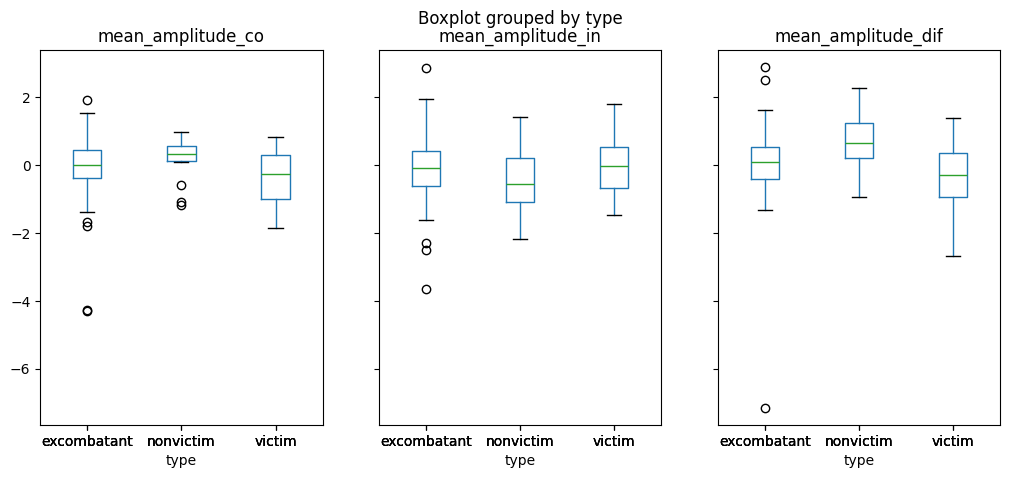

In [59]:
data_subjects.boxplot(
    by='type', 
    column=['mean_amplitude_co', 'mean_amplitude_in', 'mean_amplitude_dif'],
    figsize=(12, 5),
    layout=(1, 3),
    grid=False
    )

array([<Axes: title={'center': 'peak_latency_co'}, xlabel='type'>,
       <Axes: title={'center': 'peak_latency_in'}, xlabel='type'>,
       <Axes: title={'center': 'peak_latency_dif'}, xlabel='type'>],
      dtype=object)

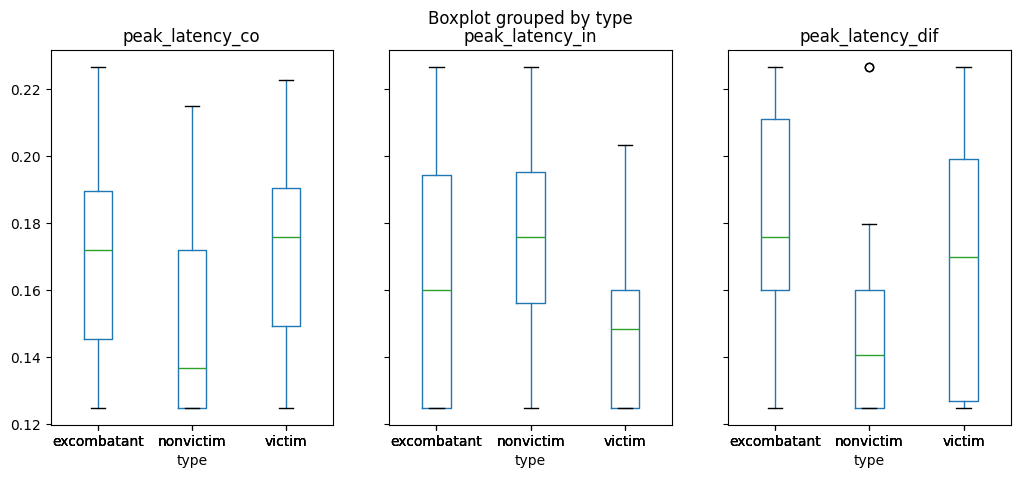

In [60]:
data_subjects.boxplot(
    by='type', 
    column=['peak_latency_co', 'peak_latency_in', 'peak_latency_dif'],
    figsize=(12, 5),
    layout=(1, 3),
    grid=False
    )

array([<Axes: title={'center': 'peak_amplitude_co'}, xlabel='type'>,
       <Axes: title={'center': 'peak_amplitude_in'}, xlabel='type'>,
       <Axes: title={'center': 'peak_amplitude_dif'}, xlabel='type'>],
      dtype=object)

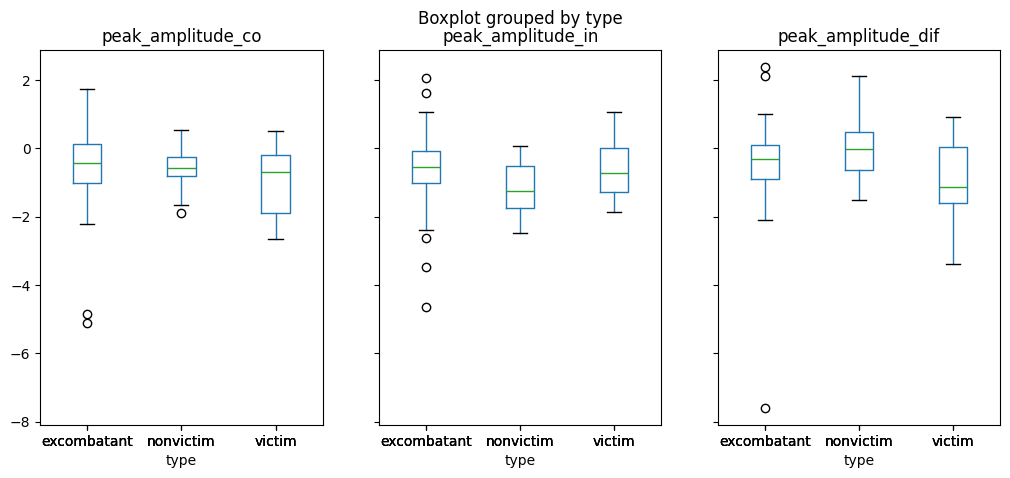

In [61]:
data_subjects.boxplot(
    by='type', 
    column=['peak_amplitude_co', 'peak_amplitude_in', 'peak_amplitude_dif'],
    figsize=(12, 5),
    layout=(1, 3),
    grid=False
    )

In [62]:
data_subjects.to_csv('data_subjects.csv', index=True)

# Gráficos

In [63]:
# Función que crea un diccionario con las ROIs por cada grupo de un factor
def dict_factor_roi(ROI_co, ROI_in, ROI_dif, df_sujetos, factor):
    grupos = df_sujetos[factor].unique().tolist()
    dict_grupos = {}
    for grupo in grupos:
        # Crear un diccionario con el nombre del grupo seleccionado, es decir 
        # si es victim, excombatant o nonvictim
        sujetos = df_sujetos[df_sujetos[factor]==grupo].index.tolist()
        sujetos_co = list({key: ROI_co[key] for key in sujetos}.values())
        sujetos_in = list({key: ROI_in[key] for key in sujetos}.values())
        sujetos_dif = list({key: ROI_dif[key] for key in sujetos}.values())
        dict_grupos[grupo] = {'co': sujetos_co, 'in': sujetos_in, 'dif': sujetos_dif}
    return dict_grupos

In [64]:
dict_grupos = dict_factor_roi(
    ROI_co=ROI_co, 
    ROI_in=ROI_in, 
    ROI_dif=ROI_dif, 
    df_sujetos=preserved, 
    factor='type'
    )

dict_grupos.keys()

dict_keys(['excombatant', 'nonvictim', 'victim'])

In [65]:
# Función que grafica los erp de cada grupo de un factor en una ROI específica
def figura_factor_roi(
    dict_grupos, 
    t_init, 
    duration, 
    conditions=['co','in'], 
    ci=False, 
    vmin=-3.0, 
    vmax=3.0
    ):
    erps = {}
    erps_all = {}
    for condition in conditions:
        for key in dict_grupos.keys():
            erps[key] = dict_grupos[key][condition]
            # Añadir un sufijo al nombre de la clave para indicar la condición
            erps[f"{key}_{condition}"] = erps.pop(key)
            erps_all = {**erps_all, **erps}

    fig = mne.viz.plot_compare_evokeds(
        evokeds=erps_all, 
        axes=None, 
        ci=ci, 
        truncate_yaxis='auto',
        truncate_xaxis=True, 
        show_sensors=False, 
        split_legend=True, 
        combine=None,
        show=False,
        )
    
    # Graficar la ventana de tiempo del ROI
    ax = fig[0].gca()
    rect = plt.Rectangle((t_init,vmin), duration, vmax-vmin, color='lightgray', alpha=0.4)
    ax.add_patch(rect)
    return ax

<Axes: xlabel='Time (s)', ylabel='µV'>

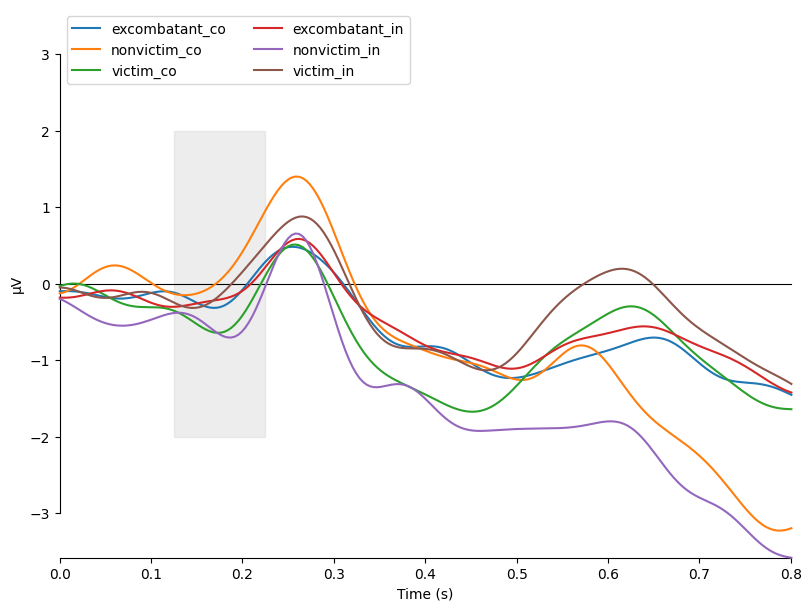

In [66]:
figura_factor_roi(
    dict_grupos, 
    conditions=['co','in'], 
    ci=False, 
    t_init=tmin, 
    duration=duration, 
    vmin=-2.0, 
    vmax=2.0
    )

<Axes: xlabel='Time (s)', ylabel='µV'>

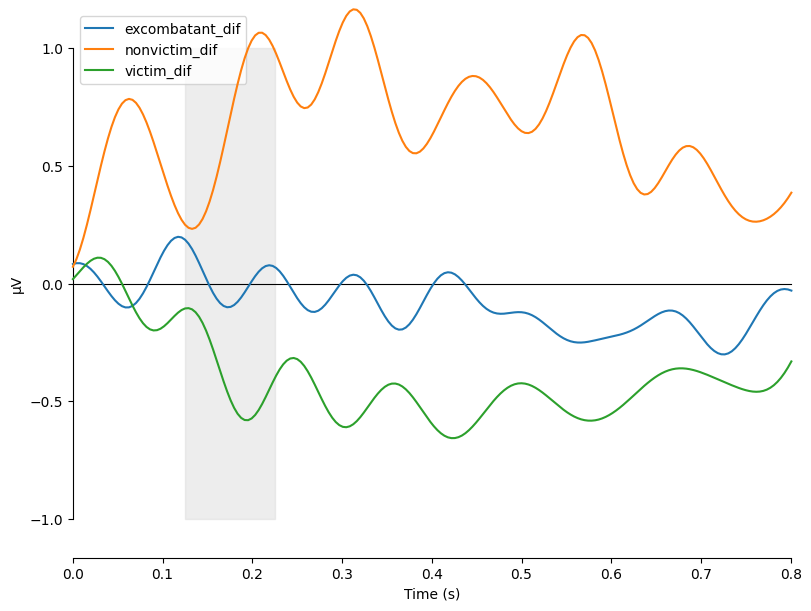

In [67]:
figura_factor_roi(
    dict_grupos, 
    conditions=['dif'], 
    ci=False, 
    t_init=tmin, 
    duration=duration, 
    vmin=-1.0, 
    vmax=1.0
    )

In [68]:
# Función que grafica los erp de cada grupo de un factor en una ROI
# y ventana de tiempo del ROI

def figura_factor_roi_ventana(
    dict_grupos, 
    t_init, 
    duration,
    conditions=['co','in'], 
    ci=False, 
    ):

    erps = {}
    erps_all = {}
    for condition in conditions:
        for key in dict_grupos.keys():
            erps[key] = dict_grupos[key][condition]
            # Añadir un sufijo al nombre de la clave para indicar la condición
            erps[f"{key}_{condition}"] = erps.pop(key)
            erps_all = {**erps_all, **erps}
    
    for key in erps_all.keys():
        for i in range(len(erps_all[key])):
            erps_all[key][i].crop(tmin=t_init, tmax=t_init+duration)
            
    fig1 = mne.viz.plot_compare_evokeds(
        evokeds=erps_all, 
        axes=None, 
        ci=ci, 
        truncate_yaxis='auto',
        truncate_xaxis=True, 
        show_sensors=False, 
        split_legend=True, 
        combine=None,
        show=False,
        )
    
    # Graficar la ventana de tiempo del ROI
    ax1 = fig1[0].gca()
    return ax1

<Axes: xlabel='Time (s)', ylabel='µV'>

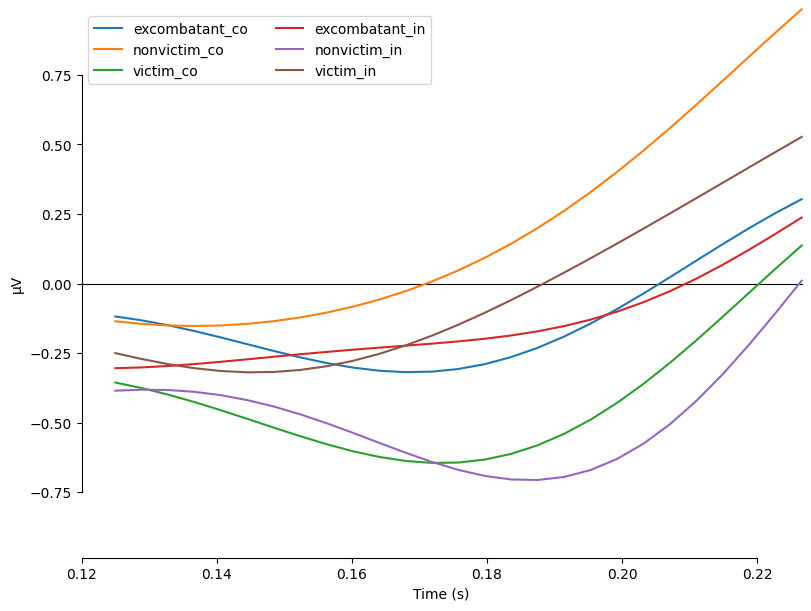

In [69]:
figura_factor_roi_ventana(
    dict_grupos, 
    conditions=['co','in'], 
    ci=False, 
    t_init=tmin,
    duration=duration, 
    )

<Axes: xlabel='Time (s)', ylabel='µV'>

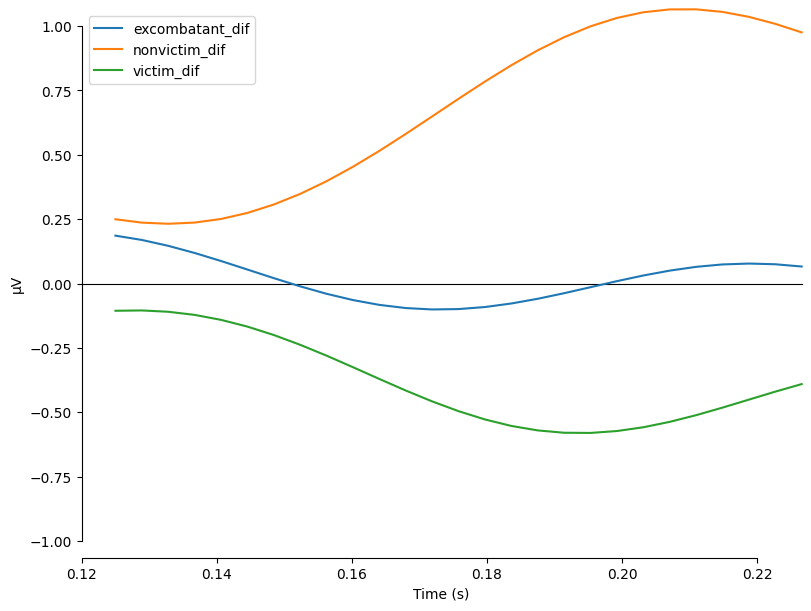

In [70]:
figura_factor_roi_ventana(
    dict_grupos, 
    conditions=['dif'], 
    ci=False, 
    t_init=tmin,
    duration=duration, 
    )

In [71]:
# mapas topográficos

dict_grupos.keys()

dict_keys(['excombatant', 'nonvictim', 'victim'])